(210, 160, 3) 228 0
Action: 5, Reward: 0.0
Action: 2, Reward: 0.0
Action: 5, Reward: 0.0
Action: 3, Reward: 0.0
Action: 3, Reward: 0.0
Action: 3, Reward: 0.0
Action: 0, Reward: 0.0
Action: 1, Reward: 0.0
Action: 3, Reward: 0.0
Action: 5, Reward: 0.0
Action: 2, Reward: 0.0
Action: 3, Reward: 0.0
Action: 4, Reward: 0.0
Action: 5, Reward: 0.0
Action: 0, Reward: 0.0
Action: 0, Reward: 0.0
Action: 0, Reward: 0.0
Action: 0, Reward: 0.0
Action: 5, Reward: 0.0
Action: 2, Reward: 0.0
Action: 0, Reward: 0.0
Action: 4, Reward: 0.0
Action: 2, Reward: 0.0
Action: 4, Reward: 0.0
Action: 5, Reward: 0.0
Action: 2, Reward: 0.0
Action: 4, Reward: 0.0
Action: 1, Reward: 0.0
Action: 2, Reward: 0.0
Action: 3, Reward: 0.0


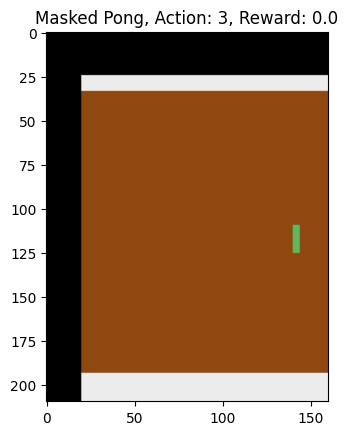

In [2]:
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt
from causal_gym.core import Task

game = "Pong"
env = gym.make(f"causal_gym/Masked{game}-v0", task=Task(learning_regime='cool'))
obs, info = env.reset()
frames = []
# frames.append(obs)
# start the game, no need to record the first frame
env.do(lambda x: 1)
print(obs.shape, obs.max(), obs.min())

for _ in range(30):
    next_obs, reward, term, trunc, info = env.see()
    action = info['natural_action']
    print(f"Action: {action}, Reward: {reward}")
    if term or trunc:
        break
    obs = next_obs
    frames.append(obs)
plt.imshow(obs)
plt.title(f"Masked {game}, Action: {action}, Reward: {reward}")
plt.show()

(210, 160, 3) 228 0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0
Action: 2, Reward: 0.0


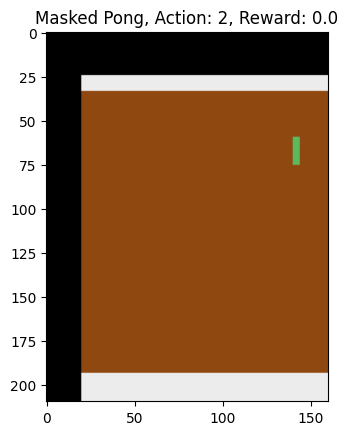

In [5]:
obs, info = env.reset()
print(obs.shape, obs.max(), obs.min())
# start the game
env.do(lambda x: 1)

for _ in range(10):
    next_obs, reward, term, trunc, info = env.do(lambda x: 2)
    print(f"Action: {2}, Reward: {reward}")
    if term or trunc:
        break
    obs = next_obs
plt.imshow(obs)
plt.title(f"Masked {game}, Action: {2}, Reward: {reward}")
plt.show()

In [6]:
import numpy as np
import gymnasium as gym
import causal_gym as cgym
import matplotlib.pyplot as plt

def display_frames(frames, figsize=(10, 8)):
    """Displays a list of frames (RGB arrays) as an animation or sequence."""
    if not frames:
        print("No frames to display.")
        return
    
    # Check if frames are Pygame surfaces or numpy arrays
    if isinstance(frames[0], np.ndarray):
        # Simple display for a few frames, or animate if many
        if len(frames) <= 5:
            fig, axes = plt.subplots(1, len(frames), figsize=figsize)
            if len(frames) == 1:
                axes = [axes] # make it iterable
            for i, frame in enumerate(frames):
                axes[i].imshow(frame)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()
        else: # Animation for many frames
            fig = plt.figure(figsize=figsize)
            plt.axis('off')
            plt.tight_layout()
            img_display = plt.imshow(frames[0])
            def animate(i):
                img_display.set_data(frames[i])
                return [img_display]
            
            from matplotlib.animation import FuncAnimation
            anim = FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
            from IPython.display import HTML
            plt.close(fig) # close the static plot
            display(HTML(anim.to_jshtml()))
            print("Displaying animation.")

In [7]:
display_frames(frames)

Displaying animation.
